# Planner Agent with LangGraph — End-to-End Complex Task

This notebook builds a **Planner–Executor–Replanner agent** for a complex business task.

### Example task

> Create an 8-week go-to-market plan for an AI interview-preparation product in India with a ₹5,00,000 budget.

The workflow:

```text
User goal
   ↓
Planner creates ordered steps
   ↓
Executor completes one step using tools
   ↓
Progress is stored in state
   ↓
Replanner decides:
   ├── Continue with remaining steps
   ├── Replace or add steps
   └── Finish with a final answer
```

### Model design

The notebook does **not duplicate the agent code for each provider**.

- One `build_model()` function uses `if/elif` to initialize a provider.
- Available providers are collected in priority order.
- One variable named `llm` is assigned.
- `llm.with_fallbacks(...)` automatically moves to the next provider if the current provider fails.

Supported providers in this notebook:

- OpenAI
- Groq


## Cell 1: Install Libraries

In [1]:
# %pip install -U langgraph langchain langchain-openai langchain-groq python-dotenv pydantic

## Cell 2: Import Libraries

In [1]:
import json
import os
from typing import Annotated, Any, Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


## Cell 3: Configure API Keys

Create a `.env` file in the same directory:

```text
OPENAI_API_KEY=your_openai_api_key
GROQ_API_KEY=your_groq_api_key

# Optional provider order:
MODEL_PROVIDERS=openai,groq
```

At least one API key must be available.


In [2]:
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY1")
GROQ_API_KEY = os.getenv("GROQ_API_KEY_S")

provider_order = [
    provider.strip().lower()
    for provider in os.getenv(
        "MODEL_PROVIDERS",
        "openai,groq",
    ).split(",")
    if provider.strip()
]

print("Requested provider order:", provider_order)
print("OpenAI configured:", bool(OPENAI_API_KEY))
print("Groq configured:", bool(GROQ_API_KEY))


Requested provider order: ['openai', 'groq']
OpenAI configured: False
Groq configured: True


## Cell 4: Single Model Factory Using `if/elif`

This is the only place where provider-specific initialization is written.


In [3]:
def build_model(provider: str):
    """Return one configured chat model for the requested provider."""

    provider = provider.strip().lower()

    if provider == "openai":
        if not OPENAI_API_KEY:
            return None

        return ChatOpenAI(
            model="gpt-4.1-mini",
            temperature=0,
            api_key=OPENAI_API_KEY,
            max_retries=1,
            timeout=45,
        )

    elif provider == "groq":
        if not GROQ_API_KEY:
            return None

        return ChatGroq(
            model="llama-3.3-70b-versatile",
            temperature=0,
            api_key=GROQ_API_KEY,
            max_retries=1,
            timeout=45,
        )

    else:
        raise ValueError(
            f"Unsupported provider: {provider}. "
            "Use 'openai' or 'groq'."
        )


## Cell 5: Build One `llm` Variable with Fallbacks

No planner, executor, or replanner code is duplicated.

The first available provider becomes primary. Remaining providers become fallbacks.


In [4]:
available_models = []

for provider in provider_order:
    model = build_model(provider)

    if model is not None:
        available_models.append(
            {
                "provider": provider,
                "model": model,
            }
        )

if not available_models:
    raise ValueError(
        "No configured model provider was found. "
        "Add OPENAI_API_KEY or GROQ_API_KEY."
    )

primary_entry = available_models[0]
fallback_entries = available_models[1:]

primary_model = primary_entry["model"]
fallback_models = [
    entry["model"]
    for entry in fallback_entries
]

llm = (
    primary_model.with_fallbacks(fallback_models)
    if fallback_models
    else primary_model
)

print("Primary provider:", primary_entry["provider"])
print(
    "Fallback providers:",
    [entry["provider"] for entry in fallback_entries]
    or "None",
)


Primary provider: groq
Fallback providers: None


# Define the Complex Task Tools

The tools use small simulated business datasets so the notebook runs without external search APIs.

In production, replace these functions with:

- web search,
- CRM,
- analytics warehouse,
- pricing service,
- project-management API,
- financial systems.


## Cell 6: Market Research Tool

In [5]:
@tool
def market_research(topic: str) -> str:
    """Return simulated market information for a product or topic."""

    research_data = {
        "ai interview preparation india": {
            "audience": [
                "Data scientists with 1–5 years of experience",
                "Machine-learning engineers",
                "Generative-AI engineers",
                "Final-year technical students",
            ],
            "pain_points": [
                "Fragmented interview resources",
                "Difficulty practising realistic mock interviews",
                "Limited feedback on answers",
                "Rapidly changing GenAI interview expectations",
            ],
            "channels": [
                "LinkedIn",
                "YouTube",
                "Technical communities",
                "Referral partnerships",
                "College and bootcamp partnerships",
            ],
            "positioning": (
                "Role-specific AI interview practice with "
                "instant feedback and progress tracking."
            ),
        }
    }

    key = topic.strip().lower()

    data = research_data.get(
        key,
        {
            "audience": ["General professional users"],
            "pain_points": ["Insufficient validated market data"],
            "channels": ["LinkedIn", "Search", "Communities"],
            "positioning": "Validate positioning with customer interviews.",
        },
    )

    return json.dumps(data, indent=2)


## Cell 7: Budget Allocation Tool

In [6]:
@tool
def allocate_budget(
    total_budget: float,
    marketing_percent: float,
    product_percent: float,
    operations_percent: float,
    contingency_percent: float,
) -> str:
    """Validate percentages and calculate a budget allocation."""

    percentages = {
        "marketing": marketing_percent,
        "product": product_percent,
        "operations": operations_percent,
        "contingency": contingency_percent,
    }

    percentage_total = sum(percentages.values())

    if round(percentage_total, 6) != 100:
        return json.dumps(
            {
                "error": (
                    "Percentages must total 100. "
                    f"Current total: {percentage_total}"
                )
            },
            indent=2,
        )

    allocation = {
        category: round(
            total_budget * percent / 100,
            2,
        )
        for category, percent in percentages.items()
    }

    return json.dumps(
        {
            "total_budget": total_budget,
            "percentages": percentages,
            "allocation": allocation,
        },
        indent=2,
    )


## Cell 8: Timeline Tool

In [7]:
@tool
def create_timeline(
    total_weeks: int,
    phases: list[str],
) -> str:
    """Distribute project phases across the available weeks."""

    if total_weeks <= 0:
        return json.dumps(
            {"error": "total_weeks must be positive."},
            indent=2,
        )

    if not phases:
        return json.dumps(
            {"error": "At least one phase is required."},
            indent=2,
        )

    base_weeks = total_weeks // len(phases)
    extra_weeks = total_weeks % len(phases)

    timeline = []
    current_week = 1

    for index, phase in enumerate(phases):
        duration = base_weeks + (
            1 if index < extra_weeks else 0
        )

        end_week = current_week + duration - 1

        timeline.append(
            {
                "phase": phase,
                "start_week": current_week,
                "end_week": end_week,
                "duration_weeks": duration,
            }
        )

        current_week = end_week + 1

    return json.dumps(
        {
            "total_weeks": total_weeks,
            "timeline": timeline,
        },
        indent=2,
    )


## Cell 9: Risk Assessment Tool

In [8]:
@tool
def assess_risks(
    product_type: str,
    launch_market: str,
) -> str:
    """Return a simulated launch-risk register."""

    risks = [
        {
            "risk": "Low early user activation",
            "probability": "Medium",
            "impact": "High",
            "mitigation": (
                "Use guided onboarding, sample interviews, "
                "and activation analytics."
            ),
        },
        {
            "risk": "High customer-acquisition cost",
            "probability": "Medium",
            "impact": "High",
            "mitigation": (
                "Test low-cost communities and referrals "
                "before scaling paid acquisition."
            ),
        },
        {
            "risk": "Weak differentiation",
            "probability": "Medium",
            "impact": "Medium",
            "mitigation": (
                "Focus positioning on role-specific mock "
                "interviews and measurable feedback."
            ),
        },
        {
            "risk": "Inaccurate AI feedback",
            "probability": "Low to Medium",
            "impact": "High",
            "mitigation": (
                "Add evaluation rubrics, expert review, "
                "guardrails, and user reporting."
            ),
        },
    ]

    return json.dumps(
        {
            "product_type": product_type,
            "launch_market": launch_market,
            "risks": risks,
        },
        indent=2,
    )


## Cell 10: KPI Design Tool

In [9]:
@tool
def design_kpis(
    business_goal: str,
    launch_weeks: int,
) -> str:
    """Return suggested launch KPIs and measurement frequency."""

    kpis = [
        {
            "name": "Landing-page conversion rate",
            "target": "8% or more",
            "frequency": "Weekly",
        },
        {
            "name": "Activated users",
            "target": "500 by the end of launch",
            "frequency": "Weekly",
        },
        {
            "name": "Mock interviews completed per user",
            "target": "3 or more",
            "frequency": "Weekly",
        },
        {
            "name": "Week-4 retention",
            "target": "25% or more",
            "frequency": "Cohort-based",
        },
        {
            "name": "Customer-acquisition cost",
            "target": "Within approved channel budget",
            "frequency": "Weekly",
        },
    ]

    return json.dumps(
        {
            "business_goal": business_goal,
            "launch_weeks": launch_weeks,
            "kpis": kpis,
        },
        indent=2,
    )


## Cell 11: Register Tools

In [10]:
tools = [
    market_research,
    allocate_budget,
    create_timeline,
    assess_risks,
    design_kpis,
]

tool_node = ToolNode(
    tools=tools,
    handle_tool_errors=True,
)

tool_map = {
    current_tool.name: current_tool
    for current_tool in tools
}
tool_map

{'market_research': StructuredTool(name='market_research', description='Return simulated market information for a product or topic.', args_schema=<class 'langchain_core.utils.pydantic.market_research'>, func=<function market_research at 0x113c47e20>),
 'allocate_budget': StructuredTool(name='allocate_budget', description='Validate percentages and calculate a budget allocation.', args_schema=<class 'langchain_core.utils.pydantic.allocate_budget'>, func=<function allocate_budget at 0x1139db060>),
 'create_timeline': StructuredTool(name='create_timeline', description='Distribute project phases across the available weeks.', args_schema=<class 'langchain_core.utils.pydantic.create_timeline'>, func=<function create_timeline at 0x113c60900>),
 'assess_risks': StructuredTool(name='assess_risks', description='Return a simulated launch-risk register.', args_schema=<class 'langchain_core.utils.pydantic.assess_risks'>, func=<function assess_risks at 0x113c60fe0>),
 'design_kpis': StructuredTool(na

## Cell 12: Bind Tools to the Same Provider Stack

The same provider order is reused. The code does not create separate executor implementations for OpenAI and Groq.


In [11]:
bound_models = [
    entry["model"].bind_tools(tools)
    for entry in available_models
]

llm_with_tools = (
    bound_models[0].with_fallbacks(
        bound_models[1:]
    )
    if len(bound_models) > 1
    else bound_models[0]
)


# Structured Outputs

The planner and replanner return JSON that is validated by Pydantic models.


## Cell 13: Define Output Schemas

In [12]:
class Plan(BaseModel):
    steps: list[str] = Field(
        description=(
            "Ordered, concrete and independently executable steps."
        )
    )


class ReplanDecision(BaseModel):
    action: Literal["continue", "finish"] = Field(
        description=(
            "Use continue when more work is required; "
            "use finish when the final response is ready."
        )
    )

    remaining_steps: list[str] = Field(
        default_factory=list,
        description=(
            "Updated remaining steps. Empty when action is finish."
        ),
    )

    final_answer: str = Field(
        default="",
        description=(
            "Final response when action is finish; "
            "otherwise an empty string."
        ),
    )


## Cell 14: Create JSON Parsers

In [13]:
plan_parser = JsonOutputParser(
    pydantic_object=Plan
)

replan_parser = JsonOutputParser(
    pydantic_object=ReplanDecision
)


# Define LangGraph State

## Cell 15: Planner Agent State

In [14]:
class PlannerState(TypedDict, total=False):
    objective: str
    plan: list[str]
    current_step: str
    past_steps: Annotated[
        list[tuple[str, str]],
        lambda old, new: old + new,
    ]
    executor_messages: Annotated[
        list[AnyMessage],
        add_messages,
    ]
    iteration: int
    max_iterations: int
    final_answer: str


State fields:

- `objective`: original user goal
- `plan`: remaining ordered tasks
- `current_step`: step currently being executed
- `past_steps`: completed step and result pairs
- `executor_messages`: temporary ReAct messages for the current step
- `iteration`: number of executor cycles
- `max_iterations`: safety limit
- `final_answer`: completed response


# Planner Node

## Cell 16: Planner Prompt

In [15]:
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a strategic planning agent.

Break the objective into a short ordered plan of
concrete, independently executable steps.

Requirements:
- Use 4 to 7 steps.
- Each step must produce useful evidence or an output.
- Include market understanding, budget, timeline,
  risks, KPIs, and final synthesis when relevant.
- Do not execute the steps.
- Return valid JSON only.

{format_instructions}
""",
        ),
        (
            "human",
            "Objective:\n{objective}",
        ),
    ]
)


## Cell 17: Planner Chain

In [16]:
planner_chain = (
    planner_prompt
    | llm
    | plan_parser
)


## Cell 18: Planner Node Function

In [17]:
def planner_node(
    state: PlannerState,
) -> dict:
    """Create the initial ordered plan."""

    result = planner_chain.invoke(
        {
            "objective": state["objective"],
            "format_instructions": (
                plan_parser.get_format_instructions()
            ),
        }
    )

    steps = result.get("steps", [])

    if not steps:
        raise ValueError(
            "Planner returned an empty plan."
        )

    return {
        "plan": steps,
        "past_steps": [],
        "iteration": 0,
        "max_iterations": state.get(
            "max_iterations",
            15,
        ),
    }


# Step Selection Node

## Cell 19: Select the Next Planned Step

In [18]:
def select_step_node(
    state: PlannerState,
) -> dict:
    """Move the first remaining plan item into current_step."""

    remaining_plan = state.get("plan", [])

    if not remaining_plan:
        return {
            "current_step": "",
            "executor_messages": [],
        }

    current_step = remaining_plan[0]

    executor_instruction = HumanMessage(
        content=(
            "Complete this single planned step:\n"
            f"{current_step}\n\n"
            "Original objective:\n"
            f"{state['objective']}\n\n"
            "Use an available tool when it provides useful "
            "evidence or an exact calculation. When the step "
            "is complete, return a concise step result."
        )
    )

    return {
        "current_step": current_step,
        "executor_messages": [
            executor_instruction
        ],
    }


# Executor ReAct Loop

## Cell 20: Executor System Prompt

In [19]:
EXECUTOR_SYSTEM_PROMPT = """
You are the execution agent inside a planner-executor system.

Complete only the current planned step.

Rules:
- Use tools when they provide evidence, calculations,
  timeline construction, risks, or KPIs.
- Do not invent tool results.
- You may call multiple tools.
- After receiving all required tool outputs, produce
  a concise but useful result for the current step.
- Do not create the overall final report.
"""


## Cell 21: Executor Agent Node

In [20]:
def executor_agent_node(
    state: PlannerState,
) -> dict:
    """Let the execution LLM answer or request tools."""

    messages = [
        SystemMessage(
            content=EXECUTOR_SYSTEM_PROMPT
        ),
        *state.get("executor_messages", []),
    ]

    response = llm_with_tools.invoke(messages)

    return {
        "executor_messages": [response],
        "iteration": state.get("iteration", 0) + 1,
    }


## Cell 22: Executor Routing Function

In [21]:
def route_executor(
    state: PlannerState,
) -> Literal[
    "executor_tools",
    "record_step",
]:
    """Route to tools when the latest AI message has tool calls."""

    if state.get("iteration", 0) >= state.get(
        "max_iterations",
        15,
    ):
        return "record_step"

    messages = state.get(
        "executor_messages",
        [],
    )

    if not messages:
        return "record_step"

    last_message = messages[-1]

    if (
        isinstance(last_message, AIMessage)
        and last_message.tool_calls
    ):
        return "executor_tools"

    return "record_step"


## Cell 23: Tool Execution Adapter

`ToolNode` normally reads a state key named `messages`.  
Our graph uses `executor_messages`, so this adapter maps the field without duplicating tool-execution logic.


In [22]:
def executor_tools_node(
    state: PlannerState,
) -> dict:
    """Execute tool calls generated by the executor agent."""

    tool_input = {
        "messages": state.get(
            "executor_messages",
            [],
        )
    }

    tool_output = tool_node.invoke(
        tool_input
    )

    return {
        "executor_messages": (
            tool_output["messages"]
        )
    }


# Record Completed Step

## Cell 24: Record Step Result

In [23]:
def record_step_node(
    state: PlannerState,
) -> dict:
    """Store the completed step and remove it from the plan."""

    messages = state.get(
        "executor_messages",
        [],
    )

    step_result = (
        messages[-1].content
        if messages
        else "No executor output was produced."
    )

    current_step = state.get(
        "current_step",
        "Unknown step",
    )

    remaining_plan = state.get(
        "plan",
        [],
    )

    if (
        remaining_plan
        and remaining_plan[0] == current_step
    ):
        remaining_plan = remaining_plan[1:]

    return {
        "past_steps": [
            (
                current_step,
                str(step_result),
            )
        ],
        "plan": remaining_plan,
        "current_step": "",
        "executor_messages": [],
    }


# Replanner Node

## Cell 25: Replanner Prompt

In [24]:
replanner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a replanning and completion agent.

Review:
- the original objective,
- completed step results,
- and remaining plan.

Choose one action:

1. continue
   - Work is still required.
   - Return a corrected remaining_steps list.
   - Remove redundant or already-completed steps.
   - Add a missing step only when necessary.

2. finish
   - The available results are sufficient.
   - Return a complete final_answer that directly
     satisfies the objective.
   - remaining_steps must be empty.

Important:
- Do not claim facts that are absent from completed results.
- The final answer should integrate the evidence, budget,
  timeline, risks, KPIs, and recommendations.
- Return valid JSON only.

{format_instructions}
""",
        ),
        (
            "human",
            """
Objective:
{objective}

Completed steps:
{past_steps}

Remaining plan:
{remaining_plan}
""",
        ),
    ]
)


## Cell 26: Replanner Chain

In [25]:
replanner_chain = (
    replanner_prompt
    | llm
    | replan_parser
)


## Cell 27: Replanner Node Function

In [26]:
def replanner_node(
    state: PlannerState,
) -> dict:
    """Decide whether to continue, modify the plan, or finish."""

    completed_text = "\n\n".join(
        [
            (
                f"Step: {step}\n"
                f"Result: {result}"
            )
            for step, result in state.get(
                "past_steps",
                [],
            )
        ]
    )

    result = replanner_chain.invoke(
        {
            "objective": state["objective"],
            "past_steps": (
                completed_text
                or "No steps completed."
            ),
            "remaining_plan": json.dumps(
                state.get("plan", []),
                indent=2,
            ),
            "format_instructions": (
                replan_parser.get_format_instructions()
            ),
        }
    )

    action = result.get(
        "action",
        "continue",
    )

    if action == "finish":
        return {
            "plan": [],
            "final_answer": result.get(
                "final_answer",
                "",
            ),
        }

    return {
        "plan": result.get(
            "remaining_steps",
            state.get("plan", []),
        ),
        "final_answer": "",
    }


## Cell 28: Route After Replanning

In [27]:
def route_after_replan(
    state: PlannerState,
) -> Literal[
    "select_step",
    "__end__",
]:
    """Continue when plan items remain; otherwise finish."""

    if state.get("final_answer"):
        return "__end__"

    if state.get("plan"):
        return "select_step"

    return "__end__"


# Build the LangGraph

## Cell 29: Construct and Compile the Graph

In [28]:
builder = StateGraph(PlannerState)

builder.add_node(
    "planner",
    planner_node,
)

builder.add_node(
    "select_step",
    select_step_node,
)

builder.add_node(
    "executor_agent",
    executor_agent_node,
)

builder.add_node(
    "executor_tools",
    executor_tools_node,
)

builder.add_node(
    "record_step",
    record_step_node,
)

builder.add_node(
    "replanner",
    replanner_node,
)

builder.add_edge(
    START,
    "planner",
)

builder.add_edge(
    "planner",
    "select_step",
)

builder.add_edge(
    "select_step",
    "executor_agent",
)

builder.add_conditional_edges(
    "executor_agent",
    route_executor,
    {
        "executor_tools": "executor_tools",
        "record_step": "record_step",
    },
)

builder.add_edge(
    "executor_tools",
    "executor_agent",
)

builder.add_edge(
    "record_step",
    "replanner",
)

builder.add_conditional_edges(
    "replanner",
    route_after_replan,
    {
        "select_step": "select_step",
        "__end__": END,
    },
)

planner_agent = builder.compile()


Graph structure:

```text
START
  ↓
Planner
  ↓
Select next step
  ↓
Executor agent
  ↓
Tool needed?
  ├── Yes → ToolNode → Executor agent
  └── No  → Record completed step
                         ↓
                      Replanner
                         ↓
              Continue or finish?
              ├── Continue → Select next step
              └── Finish   → END
```


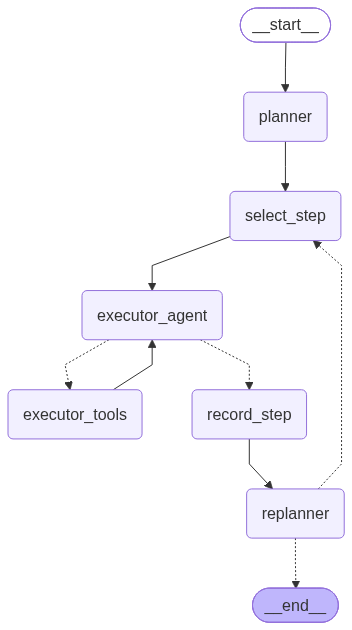

In [29]:
# ==========================================================
# Cell 6 : Visualize the LangGraph Workflow
# ==========================================================

from IPython.display import Image, display

# Display the graph
display(
    Image(
        planner_agent.get_graph().draw_mermaid_png()
    )
)

# Run the Complex Task

## Cell 30: Invoke the Planner Agent

In [30]:
objective = """
Create an 8-week go-to-market plan for an AI-powered
interview-preparation product in India.

Constraints:
- Total budget: ₹5,00,000
- Target users: data scientists, ML engineers,
  GenAI engineers, and final-year technical students
- Include target audience and positioning
- Include channel strategy
- Allocate the complete budget
- Provide an 8-week timeline
- Include major risks and mitigations
- Define measurable launch KPIs
- End with clear recommended priorities
"""


result = planner_agent.invoke(
    {
        "objective": objective,
        "max_iterations": 20,
    },
    config={
        "recursion_limit": 80,
    },
)

print(result["final_answer"])


The 8-week go-to-market plan for the AI-powered interview-preparation product in India has been completed. The plan includes market research, product development, marketing campaign, launch preparation, launch, and post-launch review. The target audience includes data scientists, ML engineers, GenAI engineers, and final-year technical students. The channel strategy includes social media marketing, influencer partnerships, and targeted online advertising. The budget allocation is ₹1,00,000 for marketing, ₹2,00,000 for product, ₹1,50,000 for operations, and ₹50,000 for contingency. The launch KPIs include website traffic, user acquisition, customer satisfaction, and revenue growth. The recommended priorities include continuous product improvement, user support, and feedback mechanisms to mitigate risks such as competition, technical issues, and user adoption. The final answer integrates the evidence, budget, timeline, risks, KPIs, and recommendations to provide a comprehensive go-to-mark

## Cell 31: Inspect the Initial/Final Plan and Completed Steps

In [31]:
print("Remaining plan:")
print(
    json.dumps(
        result.get("plan", []),
        indent=2,
    )
)

print("\nCompleted steps:")

for index, (step, step_result) in enumerate(
    result.get("past_steps", []),
    start=1,
):
    print("=" * 80)
    print(f"Step {index}: {step}")
    print(step_result)


Remaining plan:
[]

Completed steps:
Step 1: Conduct market research and analyze the target audience, including data scientists, ML engineers, GenAI engineers, and final-year technical students, to understand their needs and preferences, and allocate ₹75,000 from the budget for this step, to be completed within the first week
Conducted market research for an AI-powered interview-preparation product in India, understanding the needs and preferences of data scientists, ML engineers, GenAI engineers, and final-year technical students. Allocated ₹75,000 from the budget for this step, to be completed within the first week. The market research suggests validating positioning with customer interviews, targeting general professional users, and using LinkedIn, Search, and Communities as channels. The budget allocation is ₹1,00,000 for marketing, ₹2,00,000 for product, ₹1,50,000 for operations, and ₹50,000 for contingency. The timeline for the 8-week go-to-market plan includes market research, p

## Cell 32: Stream Graph Updates

In [ ]:
stream_input = {
    "objective": objective,
    "max_iterations": 20,
}

for event in planner_agent.stream(
    stream_input,
    config={
        "recursion_limit": 80,
    },
    stream_mode="updates",
):
    print(json.dumps(event, indent=2, default=str))
    print("-" * 100)


{
  "planner": {
    "plan": [
      "Conduct market research and analyze the target audience, including data scientists, ML engineers, GenAI engineers, and final-year technical students, to understand their needs and preferences, and allocate \u20b950,000 from the budget",
      "Develop a unique value proposition and positioning statement for the AI-powered interview-preparation product, highlighting its benefits and differentiators, and allocate \u20b920,000 from the budget",
      "Create a channel strategy, including social media marketing, influencer partnerships, and targeted online advertising, to reach the target audience, and allocate \u20b91,00,000 from the budget",
      "Design and execute a content marketing plan, including blog posts, videos, and podcasts, to educate and engage the target audience, and allocate \u20b980,000 from the budget",
      "Establish partnerships with key industry players and educational institutions to promote the product and increase its credib

# Optional Conversation Persistence

## Cell 33: Add an In-Memory Checkpointer

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

planner_agent_with_memory = builder.compile(
    checkpointer=checkpointer
)

thread_config = {
    "configurable": {
        "thread_id": "planner-demo-001"
    },
    "recursion_limit": 80,
}


## Cell 34: Run with a Thread ID

In [ ]:
memory_result = planner_agent_with_memory.invoke(
    {
        "objective": objective,
        "max_iterations": 20,
    },
    config=thread_config,
)

print(memory_result["final_answer"])


# Test Provider Selection

Change `MODEL_PROVIDERS` in `.env`:

```text
MODEL_PROVIDERS=groq,openai
```

Then restart the notebook kernel and run all cells.

The same graph code will:

1. choose Groq as primary,
2. use OpenAI as fallback,
3. assign the stack to the same `llm` variable,
4. run the same planner, executor, and replanner logic.

No agent code needs to be rewritten.


# How the Planner Agent Works

1. The user provides a complex objective.
2. `planner_node` converts it into ordered executable steps.
3. `select_step_node` chooses the first remaining step.
4. `executor_agent_node` determines whether tools are needed.
5. When tools are requested, `executor_tools_node` executes them.
6. The executor sees tool results and completes the current step.
7. `record_step_node` stores the step and its output.
8. `replanner_node` reviews all progress.
9. The replanner may:
   - keep the remaining plan,
   - remove unnecessary tasks,
   - add a missing task,
   - or produce the final answer.
10. The graph continues until the replanner returns `finish`.

## Important Production Controls

- `max_iterations` prevents excessive executor loops.
- `recursion_limit` prevents an infinite graph cycle.
- Tools validate inputs before calculation.
- Model fallbacks protect against provider failures.
- Structured JSON parsers constrain planner decisions.
- Business-critical tools should still enforce permissions and approval rules.
